# Pension model

In [1]:
import sys
import os
import pandas as pd
project_root = os.path.abspath("../")  # one level up from notebook/
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pension_model.predictor import TimeSeriesPredictor

## Import raw data

In [2]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

## Historical data and projected/scenario data

In [3]:
# Check if the length is a multiple of 69
n_years = 69
assert len(raw_df) % n_years == 0, "Data length must be a multiple of 69"

# Create dictionary of DataFrames
grouped_dfs = {
    f"group_{i}": raw_df.iloc[i*n_years:(i+1)*n_years].reset_index(drop=True)
    for i in range(len(raw_df) // n_years)
}

# Retail only real values ## df_historical_data
df_historical_data = grouped_dfs["group_0"]
df_historical_data = df_historical_data[df_historical_data['Annee'] < 2024]

# Remaining all scenario data ## df_scenarios
# Filter each DataFrame, then concatenate
filtered_dfs = [df[df['Annee'] >= 2024] for df in grouped_dfs.values()]
df_scenarios = pd.concat(filtered_dfs, ignore_index=True)

# Historical data (only once) + all scenarios
include_scenarios = True
if include_scenarios:
    # If you want all unique vales (real data + all scenarions), concatenate `df_historical_data` and `df_scenarios`
    df = pd.concat([df_historical_data, df_scenarios], ignore_index=True)
else:
    df = df_historical_data.copy()

In [4]:
from pension_model.glm_wrapper import analyze_target_distribution, create_glm_recommendations

target_analysis = analyze_target_distribution(df=df, target_col='D_PIB')
print('Recommended GLM:')
create_glm_recommendations(target_analysis)

Recommended GLM:


['GLM_Gaussian_Log', 'GLM_Gamma_Log']

---

# Instantiate the predictor and train the model

In [5]:
# Instantiate the predictor object with the target column
predictor = TimeSeriesPredictor(
    target_col='D_PIB', 
    lag_periods=[],
    rollign_windows=[],
    model_dir='../models/',
)

In [6]:
# Step 1: Load and explore data
df = predictor.load_and_explore_data(df)

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Loading and exploring data...
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Data loaded: 398 rows, 12 columns
INFO:pension_model.predictor: Data loaded: 398 rows, 12 columns
INFO:pension_model.predictor: Memory usage: 0.04 MB
INFO:pension_model.predictor: ✓ No missing values detected
INFO:pension_model.predictor: Data types:
Annee            int64
D_PIB          float64
PROD           float64
CHO            float64
MI               int64
FEC            float64
ESP_F          float64
ESP_H          float64
PIB_VAL        float64
PRELEV_REF     float64
CONTRIB_REF    float64
PIB_VOL        float64
dtype: object
INFO:pension_model.predictor: Target variable (D_PIB) statistics:
count    398.000000
mean       0.135282
std        0.004921
min        0.117761
25%        0.132409
50%        0.136231
75%

## Data visualization

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor:Data visualization and pattern analysis...
INFO:pension_model.predictor:============================================================


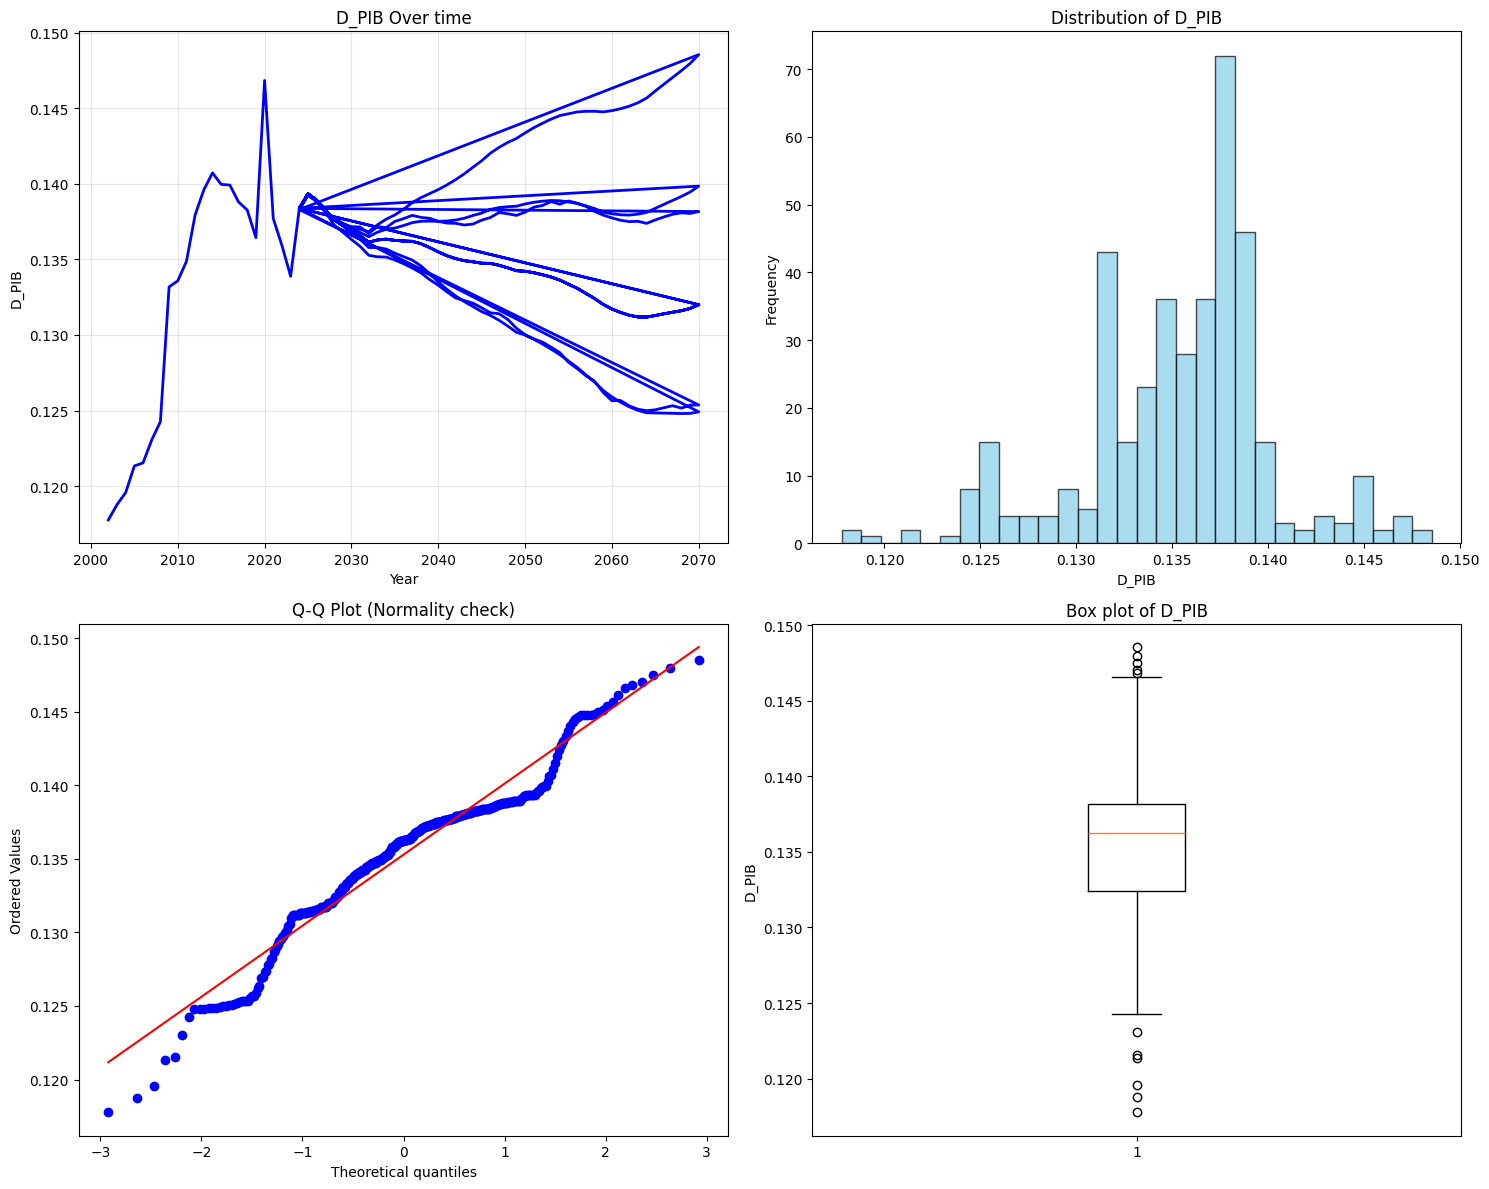

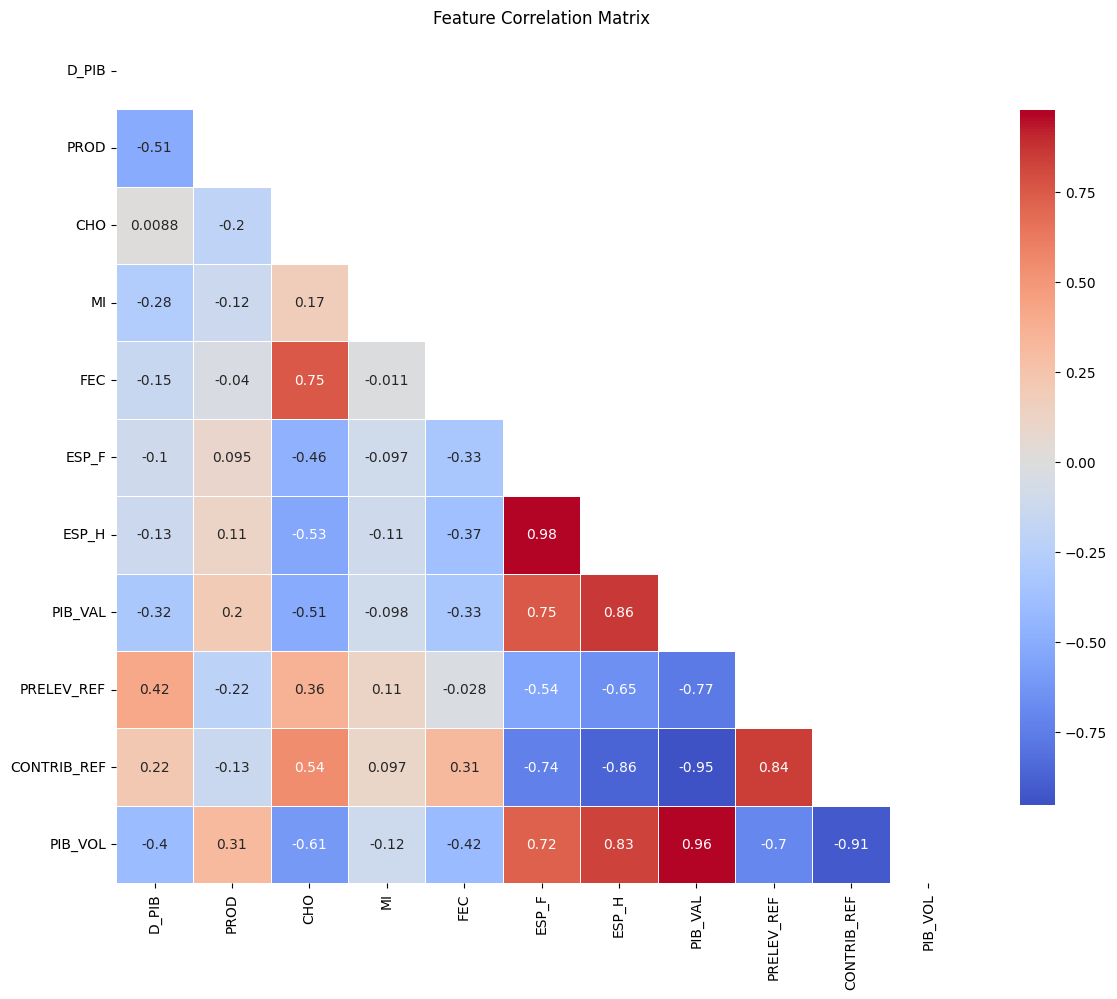

INFO:pension_model.predictor: Carried out data visualization and returning correlation matrix.


In [7]:
# Step 2: Visualize data
correlation_matrix = predictor.visualize_data()

In [8]:
correlation_matrix

,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
D_PIB,1.000000,-0.507095,0.008838,-0.277427,-0.147255,-0.104555,-0.129930,-0.315483,0.418605,0.220700,-0.403342
PROD,-0.507095,1.000000,-0.198469,-0.124735,-0.040050,0.094897,0.113337,0.197824,-0.216255,-0.131010,0.310648
CHO,0.008838,-0.198469,1.000000,0.174055,0.751548,-0.461851,-0.532904,-0.511013,0.358712,0.539909,-0.609049
MI,-0.277427,-0.124735,0.174055,1.000000,-0.011415,-0.097077,-0.107899,-0.098274,0.112094,0.097061,-0.115302
FEC,-0.147255,-0.040050,0.751548,-0.011415,1.000000,-0.333472,-0.371770,-0.327179,-0.028132,0.313504,-0.415167
ESP_F,-0.104555,0.094897,-0.461851,-0.097077,-0.333472,1.000000,0.975573,0.751834,-0.542618,-0.739529,0.720530
ESP_H,-0.129930,0.113337,-0.532904,-0.107899,-0.371770,0.975573,1.000000,0.861539,-0.654131,-0.863966,0.828914
PIB_VAL,-0.315483,0.197824,-0.511013,-0.098274,-0.327179,0.751834,0.861539,1.000000,-0.766306,-0.950731,0.963395
PRELEV_REF,0.418605,-0.216255,0.358712,0.112094,-0.028132,-0.542618,-0.654131,-0.766306,1.000000,0.843382,-0.700725
CONTRIB_REF,0.220700,-0.131010,0.539909,0.097061,0.313504,-0.739529,-0.863966,-0.950731,0.843382,1.000000,-0.907404


## Perform statistical stets on normality and stationarity

In [9]:
# Step 3: Statistical tests
predictor.statistical_tests()

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Perform statistical tests and verify assumptions...
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Normality tests:
INFO:pension_model.predictor: Jarque-Bera Test: statistic=34.6043, p-value=0.0000
INFO:pension_model.predictor: Shapiro-Wilk Test: statistic=0.9537, p-value=0.0000
INFO:pension_model.predictor: ⚠ Data may not be normally distributed
INFO:pension_model.predictor: Stationary tests:
INFO:pension_model.predictor: Augmented Dickey-Fuller Test:
INFO:pension_model.predictor:    ADF Statistic: -4.1368
INFO:pension_model.predictor:    p-value: 0.0008
INFO:pension_model.predictor:    Critical Values: {'1%': np.float64(-3.4469295619737665), '5%': np.float64(-2.8688478565083417), '10%': np.float64(-2.570662885558566)}
INFO:pension_model.predictor: ✓ Series is stationary (ADF test)


## Feature engineering

In [10]:
# Step 4: Feature engineering
X, y = predictor.feature_engineering()

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Feature engineering and selection
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Original features: 10
INFO:pension_model.predictor: Feature names: ['PROD', 'CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL']
INFO:pension_model.predictor: Skipping lag feature creation (lag_periods is empty or Annee column not found)
INFO:pension_model.predictor: Skipping rolling window feature creation (rolling_windows is empty or Annee column not found)
INFO:pension_model.predictor: Features after engineering: 10
INFO:pension_model.predictor: Samples after cleaning: 398
INFO:pension_model.predictor: No feature selection applied (number of features <= maximum allowed)
INFO:pension_model.predictor: Feature engineering completed:
INFO:pension_model.predictor:   - Created 0 new f

In [11]:
predictor.feature_names

Index(['PROD', 'CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF',
       'CONTRIB_REF', 'PIB_VOL'],
      dtype='object')

## Train different models

In [12]:
# Step 5: Prepare data
X_scaled, y = predictor.prepare_data_for_modeling()

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Data preparation and scaling...
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Applied RobustScaler to features
INFO:pension_model.predictor: Set up TimeSeriesSplit with 5 folds
INFO:pension_model.predictor: Data preparation completed. Features: 10


In [13]:
# Step 6: Train models
results = predictor.train_models()

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Model training and comparison
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Training Random Forest...
INFO:pension_model.predictor:    Performing hyperparameter tuning...
INFO:pension_model.predictor:    Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
INFO:pension_model.predictor:    Performing cross-validation...
INFO:pension_model.predictor:    CV RMSE: 0.003368 (+/- 0.003617)
INFO:pension_model.predictor: Training GLM_Gamma_Log...
INFO:pension_model.predictor:    Performing hyperparameter tuning...
INFO:pension_model.predictor:    Best parameters: {'alpha': 0.0, 'fit_intercept': True}
INFO:pension_model.predictor:    Performing cross-validation...
INFO:pension_model.predictor:    CV RMSE: 0.002507 (+/- 0.001472)
INFO:pension_model.predictor: Training GLM_Gaussi

## Model evaluation

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Model evaluation and diagnostics...
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Final Model Performance (GLM_Gamma_Log):
INFO:pension_model.predictor:    RMSE: 0.001704
INFO:pension_model.predictor:    MAE:  0.001216
INFO:pension_model.predictor:    R-squared:   0.879878


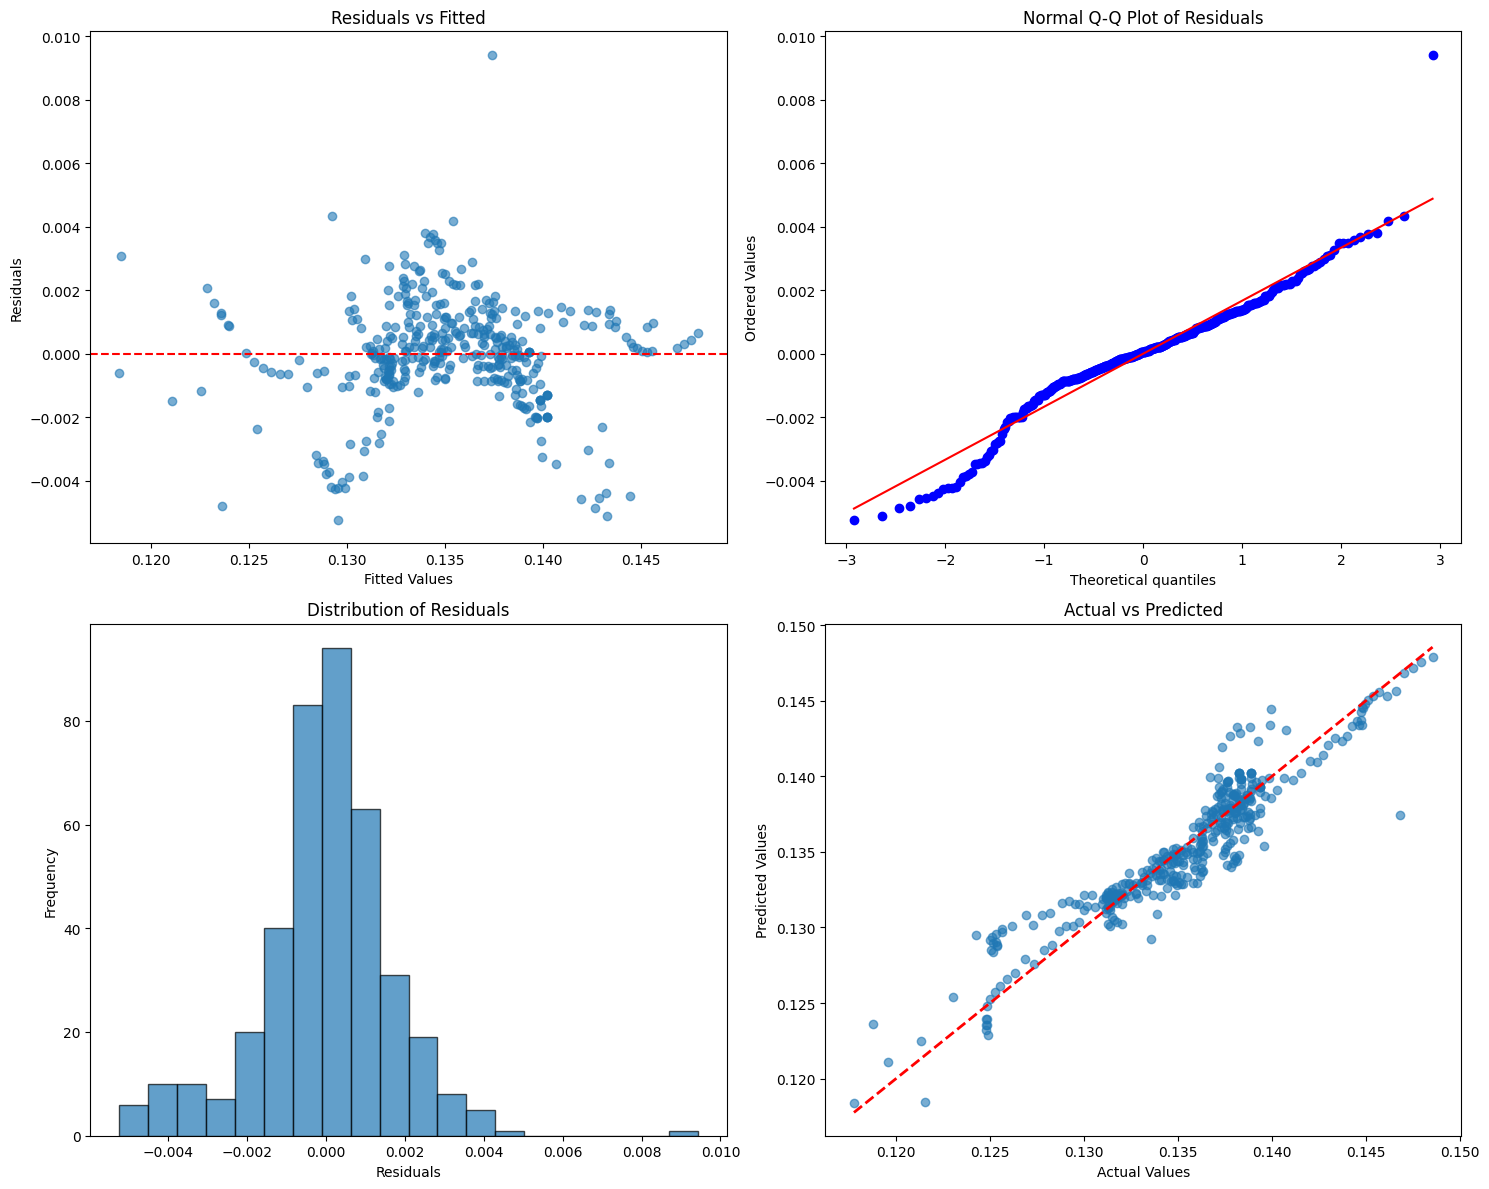

In [14]:
# Step 7: Evaluate best model
evaluation = predictor.evaluate_model()

---
---

## Model comparison

INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Model comparison summary...
INFO:pension_model.predictor:============================================================
INFO:pension_model.predictor: Model performance ranking:
           Model  CV_RMSE_Mean  CV_RMSE_Std
   GLM_Gamma_Log      0.002507     0.000736
GLM_Gaussian_Log      0.002522     0.000753
 GLM_Tweedie_1.5      0.002604     0.000723
 GLM_Tweedie_1.9      0.002604     0.000723
   Random Forest      0.003368     0.001808


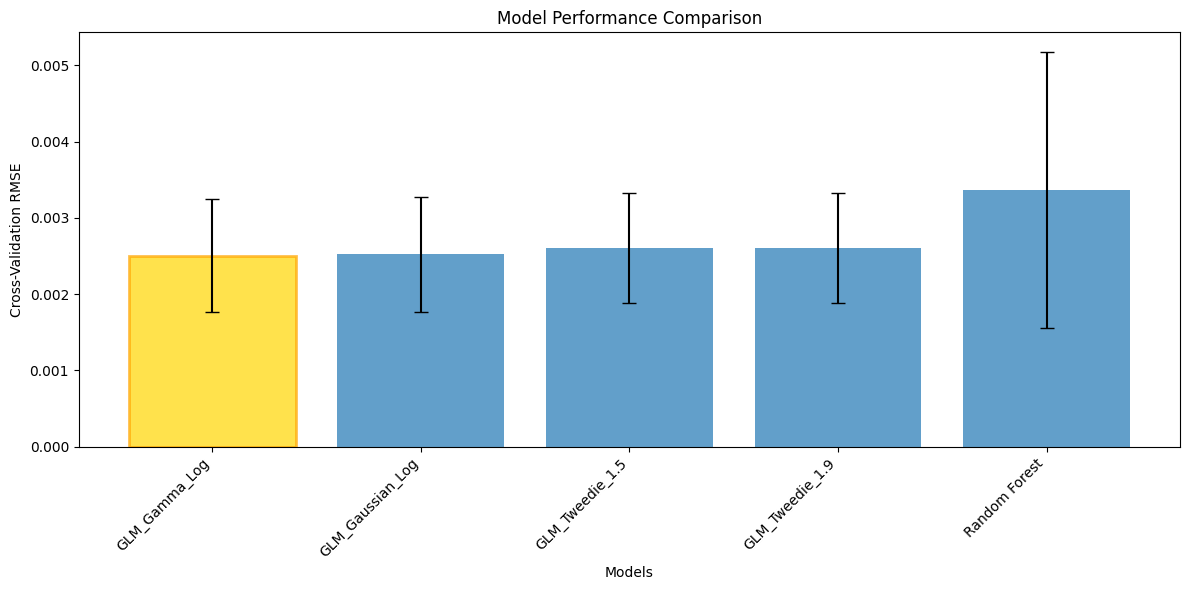

In [15]:
# Step 8: Model comparison
comparison = predictor.model_comparison_summary()

## Save best model

In [16]:
model_path = predictor.save_best_model("production_model_v1")
print(f" Model saved to: {model_path}")

INFO:pension_model.predictor: Model saved to ..\models\production_model_v1\model.pkl
INFO:pension_model.predictor: Preprocessing pipeline saved to ..\models\production_model_v1\preprocessing_pipeline.pkl
INFO:pension_model.predictor: Metadata saved to ..\models\production_model_v1\metadata.json
INFO:pension_model.predictor: Complete model package saved to ..\models\production_model_v1


 Model saved to: ..\models\production_model_v1


---
---